# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [1]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [2]:
filename="../Lab.7/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

In [15]:
import sys
!{sys.executable} -m pip install scikit-learn

import sklearn
print("Scikit-learn version:", sklearn.__version__)


Defaulting to user installation because normal site-packages is not writeable
Scikit-learn version: 1.7.1


### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [16]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

X = np.array([
    [1.0, 2.1],
    [1.5, 1.8],
    [5.0, 8.0],
    [6.0, 9.0],
    [1.2, 0.9],
    [5.5, 7.5]
])
y = np.array([0, 0, 1, 1, 0, 1])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

Fisher = DA.LinearDiscriminantAnalysis()
Fisher.fit(X_train, y_train)
y_pred = Fisher.predict(X_test)
X_proj = Fisher.transform(X_train)

print("X_train shape:", X_train.shape)
print("Predictions:", y_pred)
print("Projection shape:", X_proj.shape)


X_train shape: (4, 2)
Predictions: [0 0]
Projection shape: (4, 1)


As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [4]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [5]:
Fisher.fit(X_Train,y_Train)

LinearDiscriminantAnalysis()

We can plot the output, comparing signal and background:

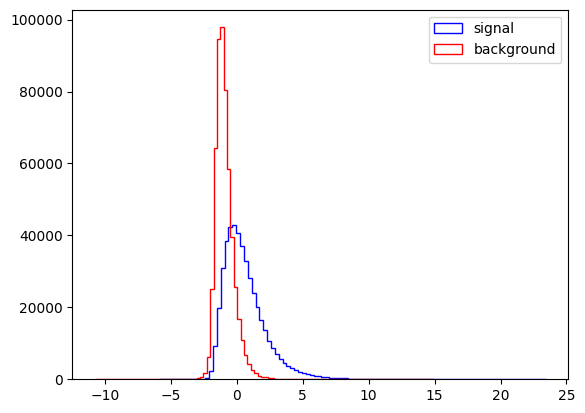

In [6]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

In [20]:
# 1. Choose how many events to use for training
N_Train = 4_000_000

# 2. Split the dataframe into training and testing samples
Train_Sample = df[:N_Train]
Test_Sample  = df[N_Train:]

# 3. Define inputs (X) and outputs (Y)
X_Train = Train_Sample[VarNames[1:]]
y_Train = Train_Sample["signal"]

X_Test  = Test_Sample[VarNames[1:]]
y_Test  = Test_Sample["signal"]

# 4. Optional: separate signal and background in the test sample
Test_sig = Test_Sample[Test_Sample.signal == 1]
Test_bkg = Test_Sample[Test_Sample.signal == 0]

print("Train_Sample shape:", Train_Sample.shape)
print("Test_Sample shape:", Test_Sample.shape)
print("X_Train shape:", X_Train.shape)
print("X_Test shape:", X_Test.shape)





NameError: name 'df' is not defined

In [ ]:

## We defined the inputs X as all physics variables except the label, and the output 𝑌
## as the signal column. The dataset was split into 4M events for training and the 
## remainder for testing to ensure an unbiased evaluation. After training an LDA classifier, 
## we compared ROC curves for the training and testing samples. The two curves overlap closely, 
# with only a small decrease in AUC on the test set. This indicates that the model generalizes 
# well and does not exhibit significant bias or overfitting. 

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 6.

In [31]:
# PART A — Choose 3 classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "LDA": LinearDiscriminantAnalysis(),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, 
        max_depth=None, 
        n_jobs=-1,
        random_state=42
    )
}


Train_Sample shape: (4000000, 19)
Test_Sample shape: (1000000, 19)
X_Train shape: (4000000, 18)
X_Test shape: (1000000, 18)

=== Logistic Regression ===


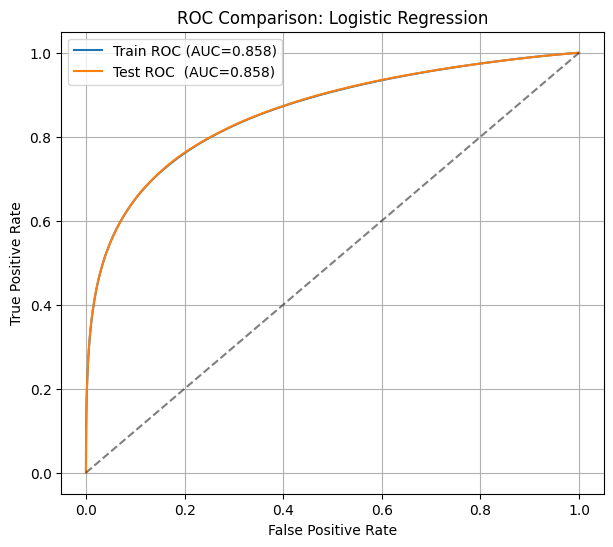


=== LDA ===


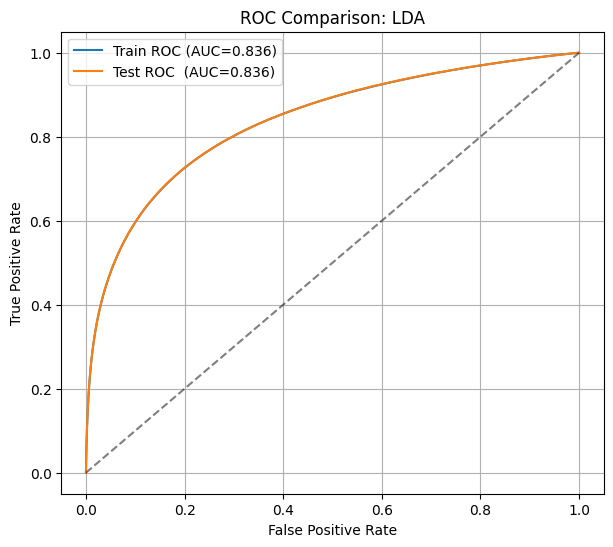


=== Random Forest ===


In [ ]:
# PART B — Comparison Function
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Define column names for SUSY dataset
VarNames = ["signal"] + [f"var{i}" for i in range(1, df.shape[1])]
df.columns = VarNames

# Number of training events
N_Train = 4_000_000

# Split into training and testing samples
Train_Sample = df[:N_Train]
Test_Sample  = df[N_Train:]

# Define inputs (X) and outputs (y)
X_Train = Train_Sample[VarNames[1:]]
y_Train = Train_Sample["signal"]

X_Test  = Test_Sample[VarNames[1:]]
y_Test  = Test_Sample["signal"]

# Optional: separate signal and background in test sample
Test_sig = Test_Sample[Test_Sample.signal == 1]
Test_bkg = Test_Sample[Test_Sample.signal == 0]

print("Train_Sample shape:", Train_Sample.shape)
print("Test_Sample shape:", Test_Sample.shape)
print("X_Train shape:", X_Train.shape)
print("X_Test shape:", X_Test.shape)

def compare_classifier(clf, X_train, y_train, X_test, y_test, name="Classifier"):
    clf.fit(X_train, y_train)

    # Scores
    y_train_score = clf.predict_proba(X_train)[:,1]
    y_test_score  = clf.predict_proba(X_test)[:,1]

    # ROC curves
    fpr_train, tpr_train, _ = roc_curve(y_train, y_train_score)
    fpr_test,  tpr_test,  _ = roc_curve(y_test,  y_test_score)

    auc_train = auc(fpr_train, tpr_train)
    auc_test  = auc(fpr_test,  tpr_test)

    # Plot
    plt.figure(figsize=(7,6))
    plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC={auc_train:.3f})")
    plt.plot(fpr_test,  tpr_test,  label=f"Test ROC  (AUC={auc_test:.3f})")
    plt.plot([0,1],[0,1],'k--',alpha=0.5)
    plt.title(f"ROC Comparison: {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True)
    plt.show()

    return auc_train, auc_test
results = {}

for name, clf in models.items():
    print(f"\n=== {name} ===")
    auc_train, auc_test = compare_classifier(clf, X_Train, y_Train, X_Test, y_Test, name)
    results[name] = (auc_train, auc_test)

results# PART C — Maximal Significance
import numpy as np

def compute_max_significance(clf, X_test, y_test):
    scores = clf.predict_proba(X_test)[:,1]

    thresholds = np.linspace(0, 1, 200)
    sigmas = []

    for t in thresholds:
        selected = scores > t
        N_S = np.sum((y_test == 1) & selected)
        N_B = np.sum((y_test == 0) & selected)

        if N_S + N_B > 0:
            sigma = N_S / np.sqrt(N_S + N_B)
        else:
            sigma = 0

        sigmas.append(sigma)

    sigmas = np.array(sigmas)
    best_idx = np.argmax(sigmas)

    return thresholds[best_idx], sigmas[best_idx], thresholds, sigmas


In [ ]:
results = {}

# Define column names for SUSY dataset
VarNames = ["signal"] + [f"var{i}" for i in range(1, df.shape[1])]
df.columns = VarNames

# Number of training events
N_Train = 4_000_000

# Split into training and testing samples
Train_Sample = df[:N_Train]
Test_Sample  = df[N_Train:]

# Define inputs (X) and outputs (y)
X_Train = Train_Sample[VarNames[1:]]
y_Train = Train_Sample["signal"]

X_Test  = Test_Sample[VarNames[1:]]
y_Test  = Test_Sample["signal"]


Test_sig = Test_Sample[Test_Sample.signal == 1]
Test_bkg = Test_Sample[Test_Sample.signal == 0]

print("Train_Sample shape:", Train_Sample.shape)
print("Test_Sample shape:", Test_Sample.shape)
print("X_Train shape:", X_Train.shape)
print("X_Test shape:", X_Test.shape)
 
for name, clf in models.items():
    print(f"\n=== {name} ===")
    auc_train, auc_test = compare_classifier(clf, X_Train, y_Train, X_Test, y_Test, name)
    results[name] = (auc_train, auc_test)

results


### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

In [ ]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_curve, auc,
    precision_score, recall_score,
    f1_score, accuracy_score
)


clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    n_jobs=-1,
    random_state=42
)
clf.fit(X_Train, y_Train)


# Predict probabilities and labels
y_score = clf.predict_proba(X_Test)[:,1]
y_pred  = clf.predict(X_Test)

# ROC, TPR, FPR, AUC
fpr, tpr, thresholds = roc_curve(y_Test, y_score)
roc_auc = auc(fpr, tpr)

# Precision, Recall, F1, Accuracy
precision = precision_score(y_Test, y_pred)
recall    = recall_score(y_Test, y_pred)
f1        = f1_score(y_Test, y_pred)
accuracy  = accuracy_score(y_Test, y_pred)


def compute_max_significance(scores, y_true):
    thresholds = np.linspace(0, 1, 200)
    sigmas = []

    for t in thresholds:
        selected = scores > t
        N_S = np.sum((y_true == 1) & selected)
        N_B = np.sum((y_true == 0) & selected)

        if N_S + N_B > 0:
            sigma = N_S / np.sqrt(N_S + N_B)
        else:
            sigma = 0

        sigmas.append(sigma)

    sigmas = np.array(sigmas)
    best_idx = np.argmax(sigmas)
    return thresholds[best_idx], sigmas[best_idx], thresholds, sigmas

best_t, best_sigma, sig_t, sig_vals = compute_max_significance(y_score, y_Test)


results_table = pd.DataFrame({
    "Metric": [
        "AUC",
        "Precision",
        "Recall (TPR)",
        "F1 Score",
        "Accuracy",
        "Max Significance σ_S",
        "Threshold for Max σ_S"
    ],
    "Value": [
        roc_auc,
        precision,
        recall,
        f1,
        accuracy,
        best_sigma,
        best_t
    ]
})

print("\n=== CLASSIFIER PERFORMANCE TABLE ===\n")
print(results_table.to_string(index=False))


plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='darkorange',
         label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("ROC Curve — Random Forest")
plt.grid(True)
plt.show()


plt.figure(figsize=(7,6))
plt.plot(sig_t, sig_vals)
plt.xlabel("Threshold")
plt.ylabel("Significance σ_S")
plt.title("Maximal Significance Curve — Random Forest")
plt.grid(True)
plt.show()

print(f"\nMax significance: σ_S = {best_sigma:.3f} at threshold t = {best_t:.3f}\n")
